In [1]:
import torch 
import re
import os
import copy
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path 
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from sklearn.preprocessing import StandardScaler
import joblib
from torch.utils.data import Dataset, DataLoader, random_split
import argparse
import torch.optim as optim
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
df_csv=pd.read_csv('df_final_nv.csv')

In [5]:
root = Path('premiere_approche/InceptionV3')
otolith_dirs = list(root.rglob("Nr*_age*"))

In [6]:
def path_images(otolith_directory):
    images = list(otolith_directory.glob("*"))
    images = [f for f in images if f.suffix.lower() in {".png"}]
 
    images_sorted = sorted(images, key=lambda x: x.name)
    path_0   = str(images_sorted[0].resolve())
    path_180 = str(images_sorted[1].resolve())
 
    return path_0, path_180

In [7]:
def extract_nr_from_folder(folder_name):
    match = re.search(r'Nr(\d+)_age*', folder_name)
    return int(match.group(1)) if match else None

In [8]:
records = []
for otlt in otolith_dirs:
    serial = int(otlt.parent.name)
    folder = otlt.name
    try:
        age_from_folder = extract_nr_from_folder(folder)
    except:
        continue

    img_0deg, img_180deg = path_images(otlt)
    records.append({
        'serial': serial,
        'folder': folder,
        'no_folder': age_from_folder,
        'img_path_0' : img_0deg,
        'img_path_180': img_180deg
    })
df_records = pd.DataFrame(records)
df_merged = df_csv.merge(
    df_records,
    left_on=['serialno', 'no'],
    right_on=['serial', 'no_folder'],
    how='inner'
)
print(f"Total après jointure : {len(df_merged)} dossiers")
df_merged.to_csv('df_merged_inception.csv', index=False)
print(f"Saved: {'df_merged_inception.csv'}  ({len(df_merged)} rows, {df_merged.shape[1]} columns)")
print(f"Columns: {list(df_merged.columns)}")

Total après jointure : 884 dossiers
Saved: df_merged_inception.csv  (884 rows, 21 columns)
Columns: ['serialno', 'no', 'weight', 'length', 'age', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningage', 'spawningzones', 'readability', 'otolithedge', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5', 'serial', 'folder', 'no_folder', 'img_path_0', 'img_path_180']


In [14]:
class OtolithDataset(Dataset):
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, tab_cols, augment=False, scaler=None):
        self.df       = df.reset_index(drop=True)
        self.tab_cols = tab_cols
        tab_data = self.df[tab_cols].values.astype(np.float32)
        if scaler is None:
            self.scaler = StandardScaler()
            self.tab_scaled = self.scaler.fit_transform(tab_data)
        else:
            self.scaler = scaler
            self.tab_scaled = self.scaler.transform(tab_data)

        base = [T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
                T.Normalize(self.IMG_MEAN, self.IMG_STD)]
        aug  = [T.Resize((IMG_SIZE, IMG_SIZE)),
                T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(), T.Normalize(self.IMG_MEAN, self.IMG_STD)]
        self.tf = T.Compose(aug if augment else base)

    def __len__(self): return len(self.df)

    def _load(self, path):
        return self.tf(Image.open(path).convert("RGB"))

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = torch.cat([self._load(row[IMG_COL_0]),
                          self._load(row[IMG_COL_180])], dim=0)
        tab  = torch.tensor(self.tab_scaled[idx], dtype=torch.float32)
        age  = torch.tensor(float(row[TARGET_COL]), dtype=torch.float32)
        return img, tab, age

In [19]:
class MultiModalRegressor_inception(nn.Module):
    def __init__(self, n_tab, hidden=256, dropout=0.3):
        super().__init__()
        base = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        base.aux_logits = False
        base.AuxLogits  = None
        base.transform_input = False 
        old = base.Conv2d_1a_3x3.conv
        new_conv = nn.Conv2d(6, old.out_channels, kernel_size=old.kernel_size,
                             stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.data = torch.cat([old.weight.data, old.weight.data], dim=1) / 2.0
        base.Conv2d_1a_3x3.conv = new_conv
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base

        self.tab_mlp = nn.Sequential(
            nn.Linear(n_tab, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(feat_dim + 64, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        return self.head(torch.cat([self.backbone(img),
                                    self.tab_mlp(tab)], dim=1)).squeeze(1)

In [20]:
CSV_PATH     = "df_merged_inception.csv"
TARGET_COL   = "age"
IMG_COL_0    = "img_path_0"
IMG_COL_180  = "img_path_180"
IMG_SIZE     = 299
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-4
VAL_FRAC     = 0.15
TEST_FRAC    = 0.15
SEED         = 42
OUTPUT_DIR   = Path("outputs/inception")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXCLUDE_COLS = {IMG_COL_0, IMG_COL_180, TARGET_COL, "serial", "folder", "no_folder","serialno","no", "spawningage", "readability", "otolithedge"}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [21]:
torch.manual_seed(SEED); np.random.seed(SEED)

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[IMG_COL_0, IMG_COL_180, TARGET_COL])
tab_cols = [c for c in df.columns
            if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df[c])]
df[tab_cols] = df[tab_cols].fillna(df[tab_cols].median())

print(f"Rows: {len(df)} | Tabular features ({len(tab_cols)}): {tab_cols}")

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n = len(df)
n_test  = int(n * TEST_FRAC)
n_val   = int(n * VAL_FRAC)
df_train = df.iloc[:n - n_val - n_test]
df_val   = df.iloc[n - n_val - n_test : n - n_test]
df_test  = df.iloc[n - n_test:]
print(f"Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")

ds_train = OtolithDataset(df_train, tab_cols, augment=True)
scaler   = ds_train.scaler
ds_val   = OtolithDataset(df_val,   tab_cols, augment=False, scaler=scaler)
ds_test  = OtolithDataset(df_test,  tab_cols, augment=False, scaler=scaler)

kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
train_dl = DataLoader(ds_train, shuffle=True,  **kw)
val_dl   = DataLoader(ds_val,   shuffle=False, **kw)
test_dl  = DataLoader(ds_test,  shuffle=False, **kw)

joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")

Rows: 884 | Tabular features (10): ['weight', 'length', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningzones', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5']
Train=620 | Val=132 | Test=132


['outputs\\inception\\scaler.pkl']

In [22]:
model     = MultiModalRegressor_inception(n_tab=len(tab_cols)).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r2": []}
best_mae, best_weights = float("inf"), None

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    losses = []
    for img, tab, age in train_dl:
        img, tab, age = img.to(device), tab.to(device), age.to(device)
        optimizer.zero_grad()
        loss = criterion(model(img, tab), age)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    # ── validate
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for img, tab, age in val_dl:
            preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
            targets.extend(age.numpy())
    preds, targets = np.array(preds), np.array(targets)
    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)

    history["train_loss"].append(np.mean(losses))
    history["val_mae"].append(mae)
    history["val_rmse"].append(rmse)
    history["val_r2"].append(r2)

    if mae < best_mae:
        best_mae = mae
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, OUTPUT_DIR / "inceptionv3_best.pth")

    if epoch % 5 == 0 or epoch == 1:
        tqdm.write(f"Epoch {epoch:3d}/{EPOCHS} | loss={np.mean(losses):.4f} | " f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

print(f"\nBest Val MAE: {best_mae:.3f}")
model.load_state_dict(best_weights)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch   1/50 | loss=54.2012 | MAE=7.017 | RMSE=7.573 | R²=-5.624
Epoch   5/50 | loss=24.0313 | MAE=5.374 | RMSE=5.816 | R²=-2.907
Epoch  10/50 | loss=6.4822 | MAE=2.128 | RMSE=2.606 | R²=0.216
Epoch  15/50 | loss=2.2309 | MAE=1.268 | RMSE=1.905 | R²=0.581
Epoch  20/50 | loss=1.4501 | MAE=1.184 | RMSE=1.790 | R²=0.630
Epoch  25/50 | loss=2.0863 | MAE=1.189 | RMSE=1.835 | R²=0.611
Epoch  30/50 | loss=1.4612 | MAE=0.994 | RMSE=1.564 | R²=0.718
Epoch  35/50 | loss=1.2899 | MAE=1.080 | RMSE=1.680 | R²=0.674
Epoch  40/50 | loss=1.3181 | MAE=0.926 | RMSE=1.490 | R²=0.744
Epoch  45/50 | loss=1.1742 | MAE=1.098 | RMSE=1.662 | R²=0.681
Epoch  50/50 | loss=1.0613 | MAE=0.993 | RMSE=1.542 | R²=0.725

Best Val MAE: 0.919


<All keys matched successfully>

TEST  MAE : 0.733 years
TEST  RMSE: 0.971 years
TEST  R²  : 0.8819


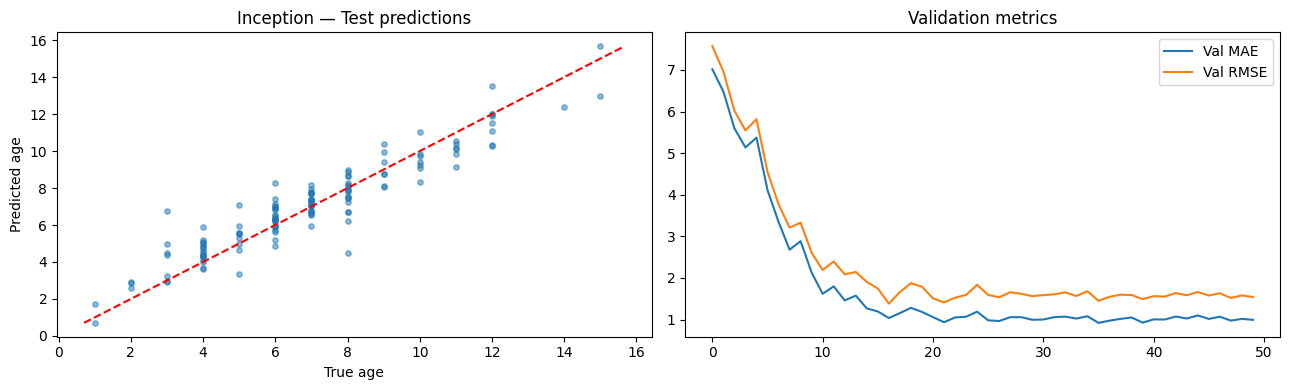

In [23]:
model.eval()
preds, targets = [], []
with torch.no_grad():
    for img, tab, age in test_dl:
        preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
        targets.extend(age.numpy())
preds, targets = np.array(preds), np.array(targets)

print(f"TEST  MAE : {mean_absolute_error(targets, preds):.3f} years")
print(f"TEST  RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f} years")
print(f"TEST  R²  : {r2_score(targets, preds):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lo, hi = min(targets.min(), preds.min()), max(targets.max(), preds.max())
axes[0].scatter(targets, preds, alpha=0.5, s=15)
axes[0].plot([lo, hi], [lo, hi], "r--")
axes[0].set_xlabel("True age"); axes[0].set_ylabel("Predicted age")
axes[0].set_title("Inception — Test predictions")

axes[1].plot(history["val_mae"], label="Val MAE")
axes[1].plot(history["val_rmse"], label="Val RMSE")
axes[1].set_title("Validation metrics"); axes[1].legend()
plt.tight_layout(); plt.show()

pd.DataFrame({"true_age": targets, "pred_age": preds}).to_csv(
    OUTPUT_DIR / "test_predictions_inception.csv", index=False)

In [24]:
LR_FINETUNE = 1e-5
EPOCHS_FINETUNE = 30

for param in model.backbone.parameters():
    param.requires_grad = True

optimizer_ft = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": LR_FINETUNE},
    {"params": model.tab_mlp.parameters(),  "lr": LR_FINETUNE * 10},
    {"params": model.head.parameters(),     "lr": LR_FINETUNE * 10},
], weight_decay=1e-4)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FINETUNE)
criterion = nn.MSELoss()

history_ft = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r2": []}
best_mae_ft = best_mae
best_weights_ft = copy.deepcopy(model.state_dict())

In [25]:
for epoch in tqdm(range(1, EPOCHS_FINETUNE + 1)):
    model.train()
    losses = []
    for img, tab, age in train_dl:
        img, tab, age = img.to(device), tab.to(device), age.to(device)
        optimizer_ft.zero_grad()
        loss = criterion(model(img, tab), age)
        loss.backward()
        optimizer_ft.step()
        losses.append(loss.item())
    scheduler_ft.step()

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for img, tab, age in val_dl:
            preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
            targets.extend(age.numpy())
    preds, targets = np.array(preds), np.array(targets)
    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)

    history_ft["train_loss"].append(np.mean(losses))
    history_ft["val_mae"].append(mae)
    history_ft["val_rmse"].append(rmse)
    history_ft["val_r2"].append(r2)

    if mae < best_mae_ft:
        best_mae_ft = mae
        best_weights_ft = copy.deepcopy(model.state_dict())
        torch.save(best_weights_ft, OUTPUT_DIR / "inception_finetuned.pth")

    if epoch % 5 == 0 or epoch == 1:
        tqdm.write(f"FT Epoch {epoch:3d}/{EPOCHS_FINETUNE} | loss={np.mean(losses):.4f} | "
                   f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

print(f"\nBest Fine-tune Val MAE: {best_mae_ft:.3f}  (before: {best_mae:.3f})")
model.load_state_dict(best_weights_ft)

  0%|          | 0/30 [00:00<?, ?it/s]

FT Epoch   1/30 | loss=1.8900 | MAE=1.158 | RMSE=1.725 | R²=0.656
FT Epoch   5/30 | loss=1.5755 | MAE=1.131 | RMSE=1.702 | R²=0.665
FT Epoch  10/30 | loss=1.3308 | MAE=0.978 | RMSE=1.486 | R²=0.745
FT Epoch  15/30 | loss=1.3186 | MAE=1.036 | RMSE=1.512 | R²=0.736
FT Epoch  20/30 | loss=1.1506 | MAE=0.936 | RMSE=1.415 | R²=0.769
FT Epoch  25/30 | loss=0.9695 | MAE=0.915 | RMSE=1.397 | R²=0.775
FT Epoch  30/30 | loss=1.1079 | MAE=0.899 | RMSE=1.353 | R²=0.788

Best Fine-tune Val MAE: 0.894  (before: 0.919)


<All keys matched successfully>

In [26]:
model.eval()
preds, targets = [], []
with torch.no_grad():
    for img, tab, age in test_dl:
        preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
        targets.extend(age.numpy())
preds, targets = np.array(preds), np.array(targets)
print("── Inception Fine-tuned ──")
print(f"TEST  MAE : {mean_absolute_error(targets, preds):.3f} years")
print(f"TEST  RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f} years")
print(f"TEST  R²  : {r2_score(targets, preds):.4f}")

── Inception Fine-tuned ──
TEST  MAE : 0.675 years
TEST  RMSE: 0.919 years
TEST  R²  : 0.8942
